# <center>**IROS Implementation**<center>

**Libraries**

In [12]:
import numpy as np
from scipy.signal import correlate

import maskpattern as mp
import plot_module as plot
import balancing as bal
import stats
import iros as sk

np.set_printoptions(precision=2, suppress=False)

In [ ]:
import importlib
importlib.reload(stats)

## **2D URA/MURA Masks with PCFOV**

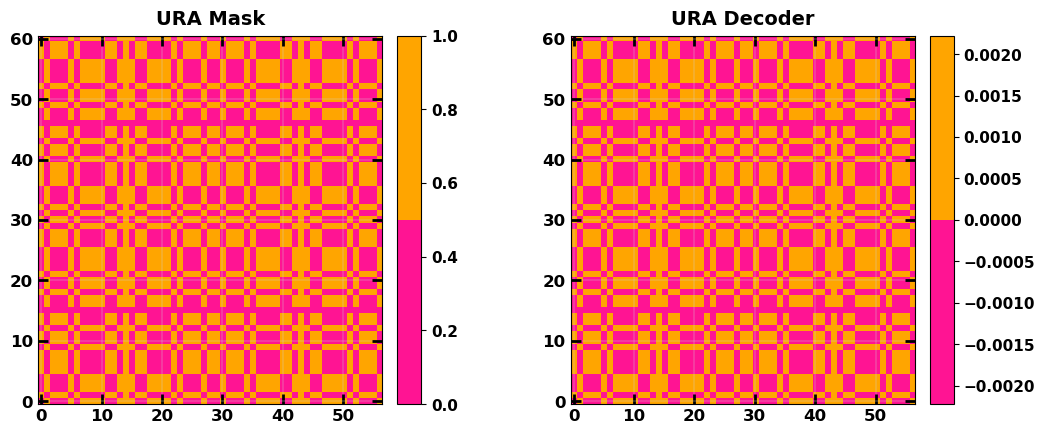

In [2]:
ura = mp.URAMaskPattern(4)
ura_pattern2D, ura_decoder2D = ura.basic_pattern, ura.basic_decoder

n, m = ura_pattern2D.shape
pad_n, pad_m = (n - 1)//2, (m - 1)//2

mask = np.pad(ura_pattern2D, pad_width=((pad_n, pad_n), (pad_m, pad_m)), mode='wrap')
decoder = np.pad(ura_decoder2D, pad_width=((pad_n, pad_n), (pad_m, pad_m)), mode='wrap')

plot.image_plot([mask, decoder],
                ["URA Mask", "URA Decoder"])

In [3]:
import collections.abc as c

def sky_image_simulation(sky_image_shape: tuple[int, int],
                         sources_flux: c.Sequence[int],
                         sources_pos: None | c.Sequence[tuple[int, int]] = None,
                         sky_background_rate: None | int = None,
                         ) -> tuple[c.Sequence, None | c.Sequence]:
    """Simulates the sky image given the sources flux."""

    # generate sky
    if sky_background_rate is None:
        sky_image = np.zeros(sky_image_shape)
    else:
        sky_image = np.random.poisson(sky_background_rate, sky_image_shape)
    
    sky_background = sky_image.copy()

    if sources_pos is None:
        sources_pos = [(np.random.randint(0, sky_image_shape[0]), np.random.randint(0, sky_image_shape[1]))
                       for _ in range(len(sources_flux))]

    # assign fluxes to point-like sources
    for i, pos in enumerate(sources_pos):
        sky_image[pos[0], pos[1]] = sources_flux[i]
    
    return sky_image, sky_background, sources_pos

### **Sky Image with Sources in the FCFOV**

- Let's first simulate a sky image and then perform the cross-correlation to obtain the sky reconstruction

- For now, I will consider only sources in the FCFOV (the sky image will comprehend the PCFOV)

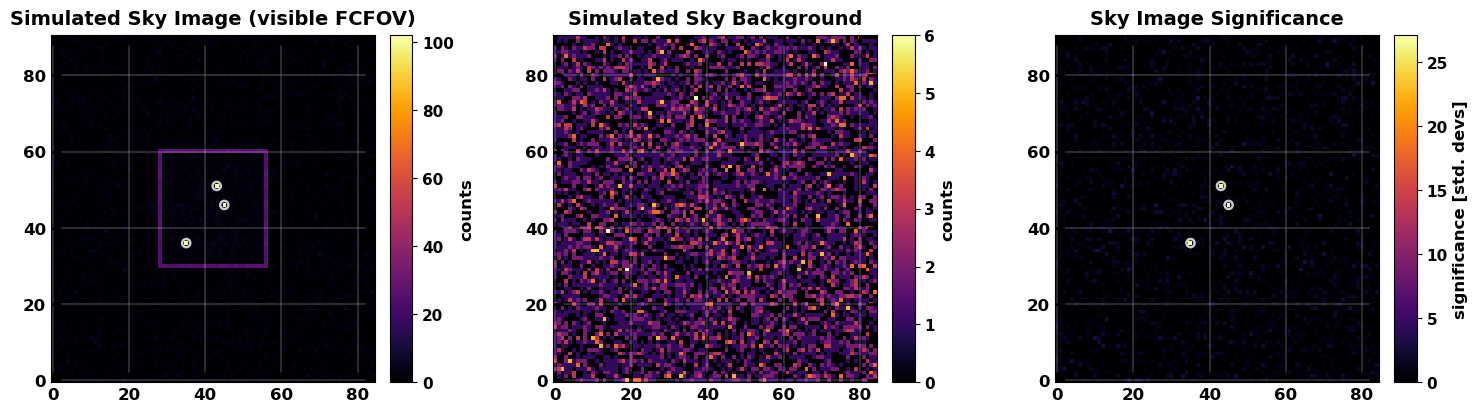

In [4]:
h, v = n - 1, m - 1
sky_shape = (n + 2*h, m + 2*v)

sources_flux = np.array([100, 100, 100])
sources_pos = [(n + 5, m + 6), (n + 15, m + 16), (h + n - 10, v + m - 14)]
sky_background_rate = 1

sky_image, sky_background, sources_pos = sky_image_simulation(sky_shape, sources_flux, sources_pos, sky_background_rate)
sky_significance = stats.significance(sky_image, sky_background_rate)

highlight_fcfov = True
if highlight_fcfov:
    base = np.ones((n - 2, m - 2))
    c_edge = np.pad(base, pad_width=[(1, 1), (1, 1)], constant_values=sources_flux.max()//4)

    sky_image_wfcfov = sky_image.copy()
    sky_image_wfcfov[h : -h, v : -v] += c_edge

    plot.image_plot([sky_image_wfcfov, sky_background, sky_significance],
                    ["Simulated Sky Image (visible FCFOV)", "Simulated Sky Background", "Sky Image Significance"],
                    cbarlabel=["counts", "counts", "significance [std. devs]"], 
                    cbarcmap=["inferno"]*3,
                    simulated_sources=[sources_pos, None, sources_pos])

else:
    plot.image_plot([sky_image, sky_background],
                    ["Simulated Sky Image", "Simulated Sky Background"],
                    cbarcmap=["inferno", "inferno"],
                    simulated_sources=[sources_pos, None])

/tmp/ipykernel_1308/1279592809.py:13: RuntimeWarning: invalid value encountered in sqrt
  snr = bal_sky_reconstruction/np.sqrt(balskyrec_var + 1e-8)


S_hat[0] - S[0]: 1.2146943825796654
STD_S_hat[0]: 2.9025249785666367

S_hat[1] - S[1]: -2.4705171987127414
STD_S_hat[1]: 2.902528973081974

S_hat[2] - S[2]: -3.412675080425032
STD_S_hat[2]: 2.9025289237670036



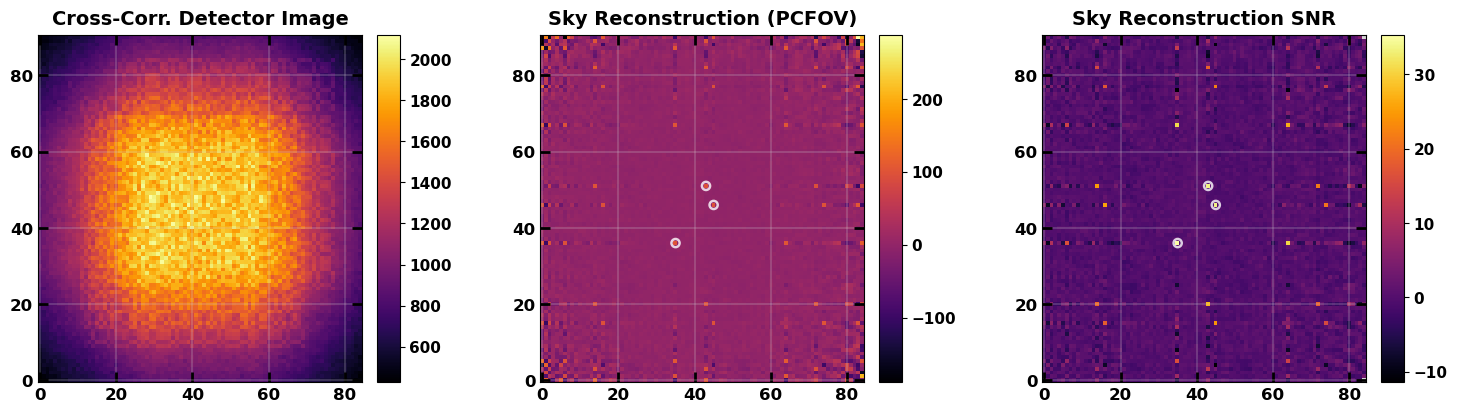

In [6]:
cc_detector_image = correlate(mask, sky_image, mode='full')[h : -h, v : -v]
fcfov_detector_image = cc_detector_image[h : -h, v : -v]

bulk_array = np.ones(fcfov_detector_image.shape)
balancing = bal.BalancedSkyReconstruction_Goldwurm(mask, decoder, bulk_array)
bal_sky_reconstruction, balskyrec_var = balancing.balanced_sky_reconstruction(fcfov_detector_image)

threshold = 300
post_bal_sky_reconstruction = bal_sky_reconstruction.copy()
post_bal_sky_reconstruction[bal_sky_reconstruction > threshold] = 0     # remove artifacts
post_bal_sky_reconstruction[bal_sky_reconstruction < -threshold] = 0

snr = bal_sky_reconstruction/np.sqrt(balskyrec_var + 1e-8)

for idx, pos in enumerate(sources_pos):
    print(f"S_hat[{idx}] - S[{idx}]: {bal_sky_reconstruction[*pos] - sky_image[*pos]}\n"
          f"STD_S_hat[{idx}]: {np.sqrt(balskyrec_var[*pos])}\n")

plot.image_plot([cc_detector_image, post_bal_sky_reconstruction, snr],
                ["Cross-Corr. Detector Image", "Sky Reconstruction (PCFOV)", "Sky Reconstruction SNR"],
                cbarcmap=["inferno"]*3,
                simulated_sources=[None, sources_pos, sources_pos])

**First Iteration**

- Let's start identifying the most brilliant source in the sky image reconstructed by cross-correlation.

- To achieve this we must first set a significance threshold (before setting a threshold it is better to check the normality of the reconstructed sky, as in `variance_SNR.ipynb`)

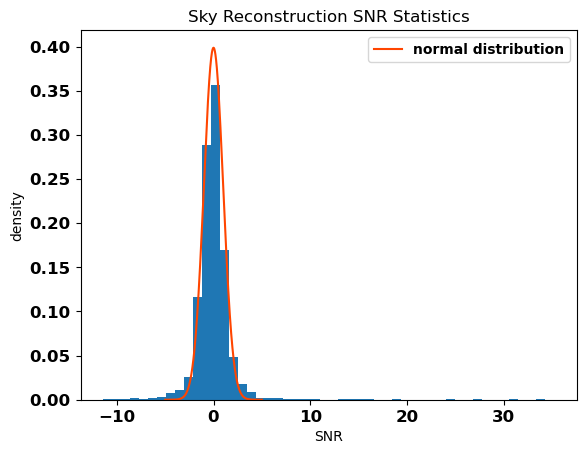

In [7]:
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.hist(snr.reshape(-1), bins=50, density= True)
plt.plot(x := np.linspace(-5, 5, 1000), norm.pdf(x), color="OrangeRed", label="normal distribution")
plt.title("Sky Reconstruction SNR Statistics")
plt.xlabel("SNR")
plt.ylabel("density")
plt.legend()
plt.show()

- If now one wants to search for outliers (e.g. the sources) with SNR over $k\sigma$ threshold:

In [8]:
k = 25
peaks_pos = np.argwhere(snr > k).T
peaks_snr_values = snr[*peaks_pos]

print(f"\n# of simulated sources: {len(sources_flux)}"
      f"\n# of outliers with SNR(σ) over {k}: {len(peaks_pos[0])}")


# of simulated sources: 3
# of outliers with SNR(σ) over 25: 8


- now I take the most significant source and build a shadowgram for it

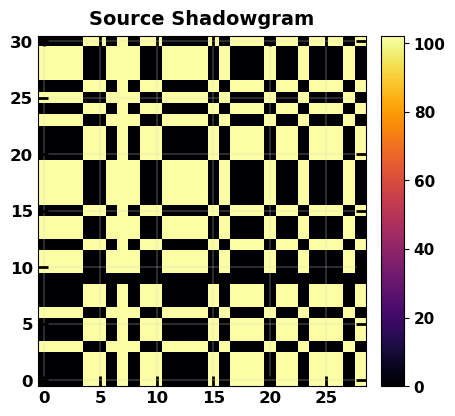

In [9]:
def shadowgram(pos: tuple, counts: int):

    s = np.zeros(sky_shape)
    s[*pos] = counts
    s_d_img = correlate(mask, s, mode='full')[2*h : -2*h, 2*v : -2*v]

    assert s_d_img.shape == fcfov_detector_image.shape

    return s_d_img



higher_snr = peaks_snr_values.max()
loc = np.argwhere(snr == higher_snr).T

source_shadowgram = shadowgram(loc, bal_sky_reconstruction[*loc])

plot.image_plot([source_shadowgram],
                [f"Source Shadowgram"],
                cbarcmap=["inferno"])

- Now let's subtract this shadowgram to the detector image and decode the result

/tmp/ipykernel_1308/1170369742.py:10: RuntimeWarning: invalid value encountered in sqrt
  iros1_snr = iros1_sky_reconstruction/np.sqrt(iros1_balskyrec_var + 1e-8)


IROS1_S_hat[0] - S[0]: -101.00000000000068
IROS1_STD_S_hat[0]: 2.8631289677394265

IROS1_S_hat[1] - S[1]: -2.356692372006819
IROS1_STD_S_hat[1]: 2.8630445722721785

IROS1_S_hat[2] - S[2]: -3.298850253718882
IROS1_STD_S_hat[2]: 2.863044522277103



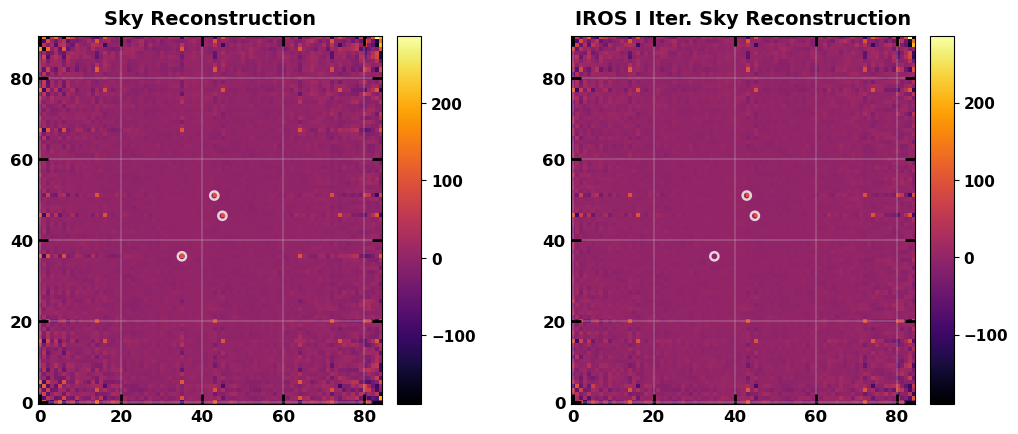

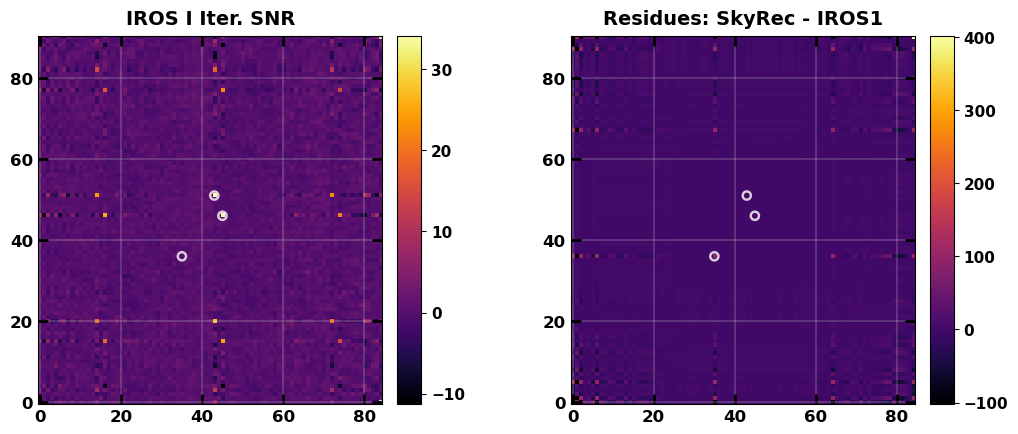

In [10]:
iros1_detector_image = fcfov_detector_image - source_shadowgram

iros1_sky_reconstruction, iros1_balskyrec_var = balancing.balanced_sky_reconstruction(iros1_detector_image)

threshold = 300
post_iros1_sky_reconstruction = iros1_sky_reconstruction.copy()
post_iros1_sky_reconstruction[iros1_sky_reconstruction > threshold] = 0     # remove artifacts
post_iros1_sky_reconstruction[iros1_sky_reconstruction < -threshold] = 0

iros1_snr = iros1_sky_reconstruction/np.sqrt(iros1_balskyrec_var + 1e-8)

for idx, pos in enumerate(sources_pos):
    print(f"IROS1_S_hat[{idx}] - S[{idx}]: {iros1_sky_reconstruction[*pos] - sky_image[*pos]}\n"
          f"IROS1_STD_S_hat[{idx}]: {np.sqrt(iros1_balskyrec_var[*pos])}\n")

plot.image_plot([post_bal_sky_reconstruction, post_iros1_sky_reconstruction],
                ["Sky Reconstruction", "IROS I Iter. Sky Reconstruction"],
                cbarcmap=["inferno"]*2,
                simulated_sources=[sources_pos, sources_pos])

plot.image_plot([iros1_snr, post_bal_sky_reconstruction - post_iros1_sky_reconstruction],
                ["IROS I Iter. SNR", "Residues: SkyRec - IROS1"],
                cbarcmap=["inferno"]*2,
                simulated_sources=[sources_pos, sources_pos])

**Second Iteration**

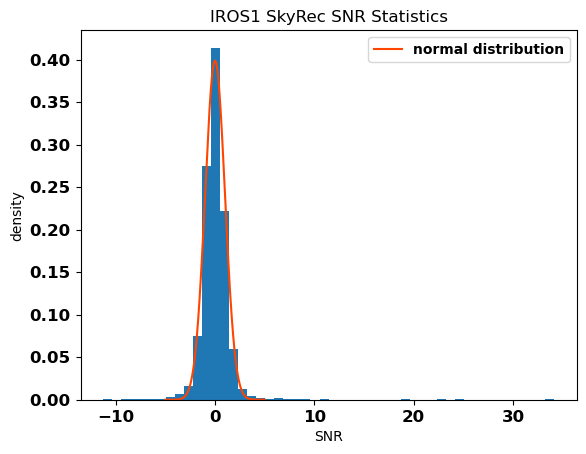

In [11]:
plt.hist(iros1_snr.reshape(-1), bins=50, density= True)
plt.plot(x := np.linspace(-5, 5, 1000), norm.pdf(x), color="OrangeRed", label="normal distribution")
plt.title("IROS1 SkyRec SNR Statistics")
plt.xlabel("SNR")
plt.ylabel("density")
plt.legend()
plt.show()


# of outliers with SNR(σ) over 25: 4


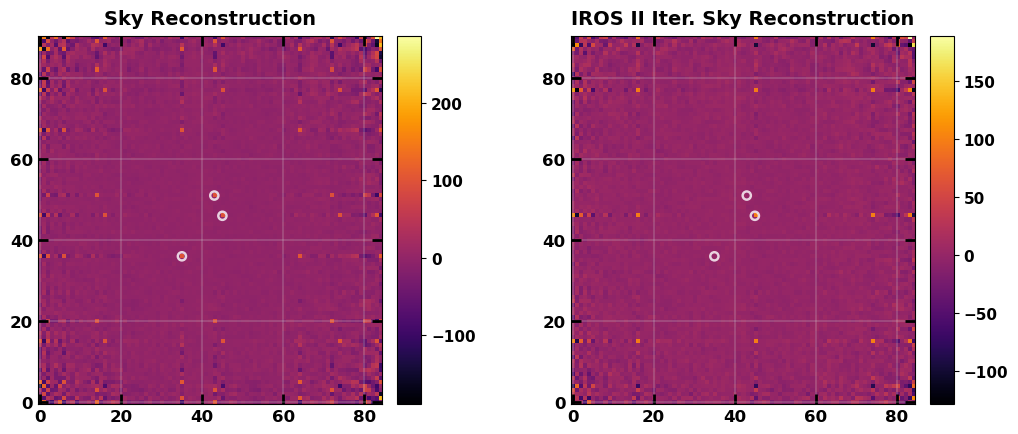

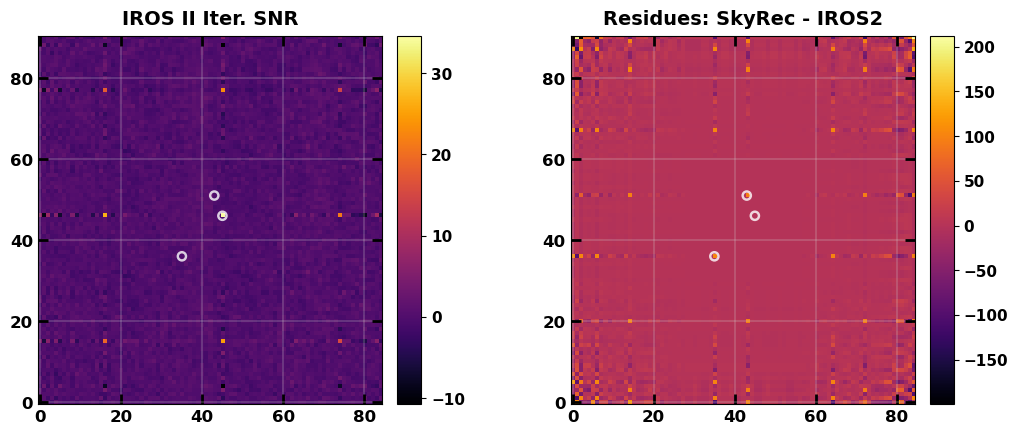

In [12]:
k = 25
peaks_pos = np.argwhere(iros1_snr > k).T
peaks_snr_values = iros1_snr[*peaks_pos]

print(f"\n# of outliers with SNR(σ) over {k}: {len(peaks_pos[0])}")

higher_snr = peaks_snr_values.max()
loc = np.argwhere(iros1_snr == higher_snr).T

source_shadowgram = shadowgram(loc, iros1_sky_reconstruction[*loc])

iros2_detector_image = iros1_detector_image - source_shadowgram

iros2_sky_reconstruction, iros2_balskyrec_var = balancing.balanced_sky_reconstruction(iros2_detector_image)

threshold = 300
post_iros2_sky_reconstruction = iros2_sky_reconstruction.copy()
post_iros2_sky_reconstruction[iros2_sky_reconstruction > threshold] = 0     # remove artifacts
post_iros2_sky_reconstruction[iros2_sky_reconstruction < -threshold] = 0

iros2_snr = iros2_sky_reconstruction/np.sqrt(iros2_balskyrec_var + 1e-8)

plot.image_plot([post_bal_sky_reconstruction, post_iros2_sky_reconstruction],
                ["Sky Reconstruction", "IROS II Iter. Sky Reconstruction"],
                cbarcmap=["inferno"]*2,
                simulated_sources=[sources_pos, sources_pos])

plot.image_plot([iros2_snr, post_bal_sky_reconstruction - post_iros2_sky_reconstruction],
                ["IROS II Iter. SNR", "Residues: SkyRec - IROS2"],
                cbarcmap=["inferno"]*2,
                simulated_sources=[sources_pos, sources_pos])

**Third Iteration**

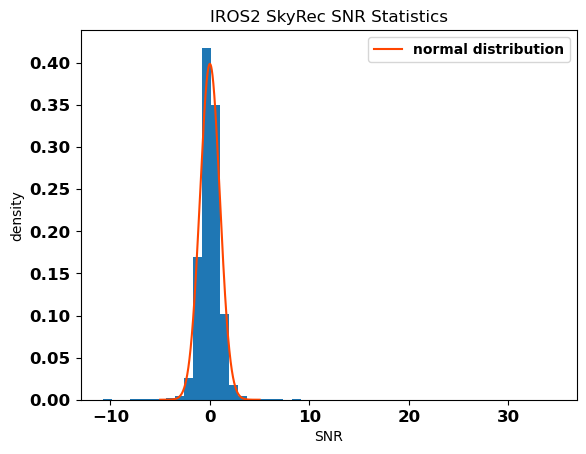

In [13]:
plt.hist(iros2_snr.reshape(-1), bins=50, density= True)
plt.plot(x := np.linspace(-5, 5, 1000), norm.pdf(x), color="OrangeRed", label="normal distribution")
plt.title("IROS2 SkyRec SNR Statistics")
plt.xlabel("SNR")
plt.ylabel("density")
plt.legend()
plt.show()


# of outliers with SNR(σ) over 25: 2


/tmp/ipykernel_1308/4179493638.py:21: RuntimeWarning: invalid value encountered in sqrt
  iros3_snr = iros3_sky_reconstruction/np.sqrt(iros3_balskyrec_var + 1e-8)


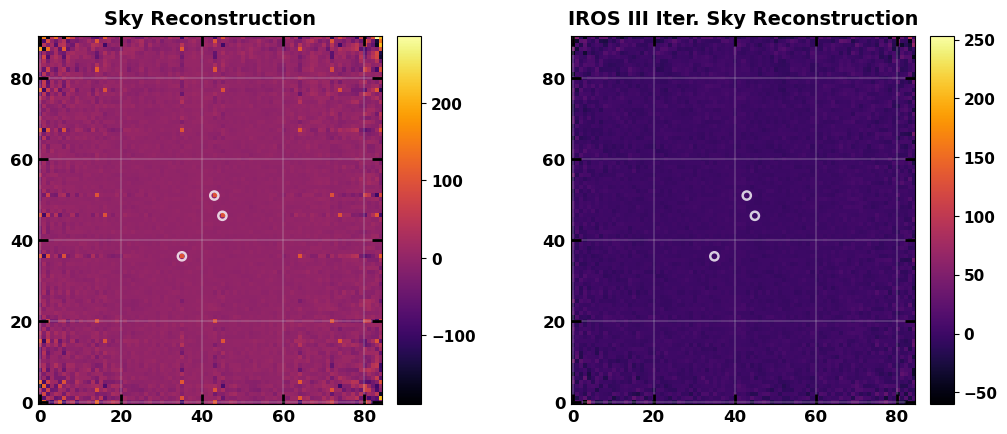

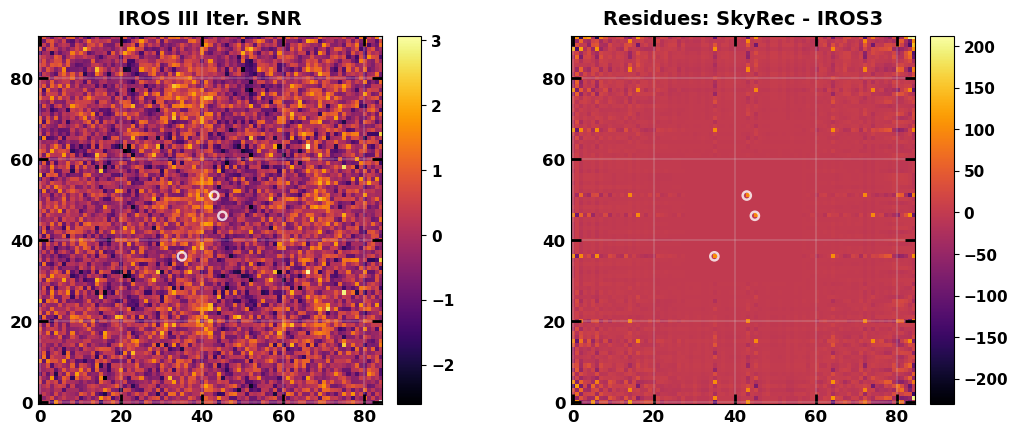

In [14]:
k = 25
peaks_pos = np.argwhere(iros2_snr > k).T
peaks_snr_values = iros2_snr[*peaks_pos]

print(f"\n# of outliers with SNR(σ) over {k}: {len(peaks_pos[0])}")

higher_snr = peaks_snr_values.max()
loc = np.argwhere(iros2_snr == higher_snr).T

source_shadowgram = shadowgram(loc, iros2_sky_reconstruction[*loc])

iros3_detector_image = iros2_detector_image - source_shadowgram

iros3_sky_reconstruction, iros3_balskyrec_var = balancing.balanced_sky_reconstruction(iros3_detector_image)

threshold = 300
post_iros3_sky_reconstruction = iros3_sky_reconstruction.copy()
post_iros3_sky_reconstruction[iros3_sky_reconstruction > threshold] = 0     # remove artifacts
post_iros3_sky_reconstruction[iros3_sky_reconstruction < -threshold] = 0

iros3_snr = iros3_sky_reconstruction/np.sqrt(iros3_balskyrec_var + 1e-8)

plot.image_plot([post_bal_sky_reconstruction, post_iros3_sky_reconstruction],
                ["Sky Reconstruction", "IROS III Iter. Sky Reconstruction"],
                cbarcmap=["inferno"]*2,
                simulated_sources=[sources_pos, sources_pos])

plot.image_plot([iros3_snr, post_bal_sky_reconstruction - post_iros3_sky_reconstruction],
                ["IROS III Iter. SNR", "Residues: SkyRec - IROS3"],
                cbarcmap=["inferno"]*2,
                simulated_sources=[sources_pos, sources_pos])

- In this simple case IROS managed to remove the sources by considering the max value of the SNR

- However, if the fluxes from the sources are not the same, this approach may become more complex, since there is also the effect of the PCFOV (i.e. of the brightest ghost peaks, even without sources in this zone)

- If the SNR from a FCFOV source ghost peak is higher than the SNR of a proper source (always in the FCFOV), the iteration will be applied to this ghost peak and not to the true source

**Sky Image Reconstruction**

- Let's look at the true sources and at the reconstructed ones

In [15]:
rec_sources_counts = []

for idx, pos in enumerate(sources_pos):
    print(
        f"Source S[{idx}] counts: {sky_image[*pos]:.0f}\n"
        f"Reconstructed Source S_hat[{idx}] counts: {bal_sky_reconstruction[*pos]:.0f} +/- {np.sqrt(balskyrec_var[*pos]):.0f}\n"
    )
    rec_sources_counts.append(bal_sky_reconstruction[*pos])

Source S[0] counts: 101
Reconstructed Source S_hat[0] counts: 102 +/- 3

Source S[1] counts: 100
Reconstructed Source S_hat[1] counts: 98 +/- 3

Source S[2] counts: 101
Reconstructed Source S_hat[2] counts: 98 +/- 3



In [16]:
# the sky background rate can be estimated by subtracting the total detector counts and the sum of the counts from the recovered sources

open_fraction = ura_pattern2D.sum()/np.prod(ura_pattern2D.shape)
estim_sky_bg_rate = open_fraction*(fcfov_detector_image.sum()/ura_pattern2D.sum() - sum(rec_sources_counts))/(n*m)  # include normalization

print(
    f"True sky background rate: {sky_background_rate}\n"
    f"Estimated sky background flux counts per mask element: {estim_sky_bg_rate:.0f} +/- {np.sqrt(estim_sky_bg_rate):.0f}"
    )

True sky background rate: 1
Estimated sky background flux counts per mask element: 2 +/- 1


- Let's build a method to incorporate IROS

In [11]:
import iros as sk

- Let's simulate a new sky image and proceed with the reconstruction

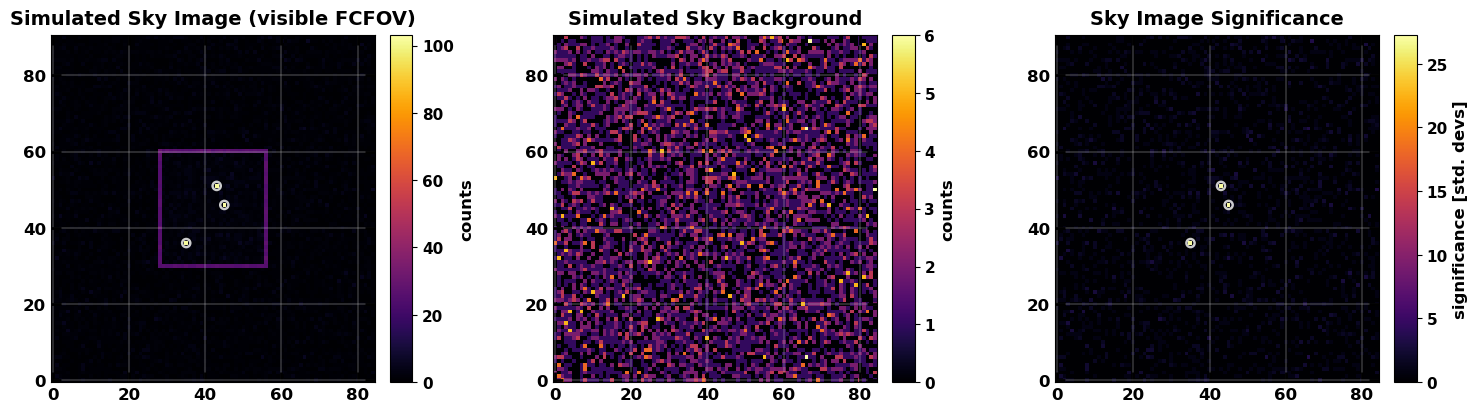

/tmp/ipykernel_1663/596824917.py:38: RuntimeWarning: invalid value encountered in sqrt
  snr = np.nan_to_num(sky_reconstruction/np.sqrt(skyrec_var + 1e-8))


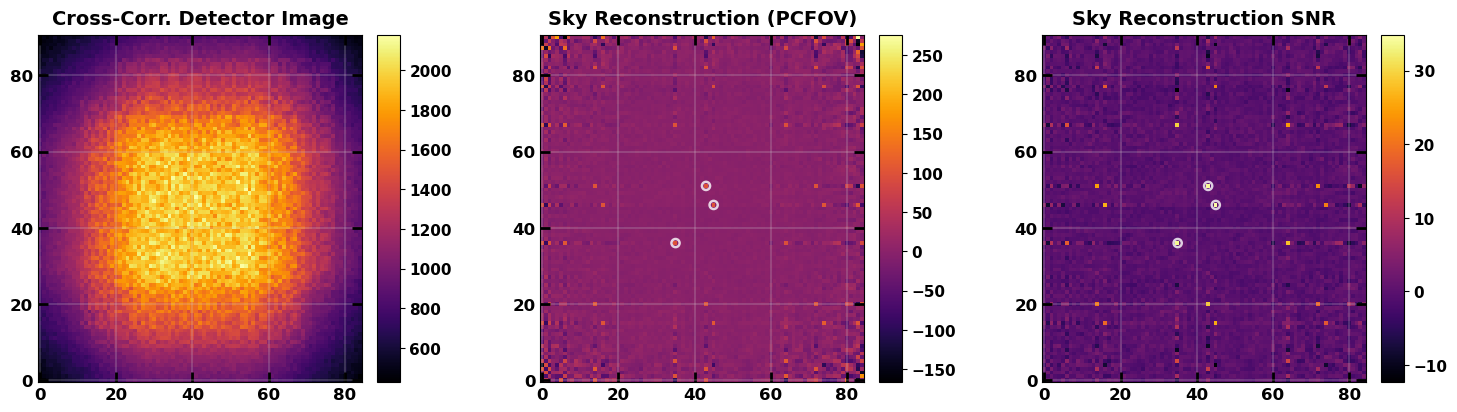

In [73]:
h, v = n - 1, m - 1
sky_shape = (n + 2*h, m + 2*v)

sources_flux = np.array([100, 100, 100])
sources_pos = [(n + 5, m + 6), (n + 15, m + 16), (h + n - 10, v + m - 14)]
sky_background_rate = 1

sky_image, sky_background, sources_pos = sky_image_simulation(sky_shape, sources_flux, sources_pos, sky_background_rate)
sky_significance = stats.significance(sky_image, sky_background_rate)

highlight_fcfov = True
if highlight_fcfov:
    base = np.ones((n - 2, m - 2))
    c_edge = np.pad(base, pad_width=[(1, 1), (1, 1)], constant_values=sources_flux.max()//4)

    sky_image_wfcfov = sky_image.copy()
    sky_image_wfcfov[h : -h, v : -v] += c_edge

    plot.image_plot([sky_image_wfcfov, sky_background, sky_significance],
                    ["Simulated Sky Image (visible FCFOV)", "Simulated Sky Background", "Sky Image Significance"],
                    cbarlabel=["counts", "counts", "significance [std. devs]"], 
                    cbarcmap=["inferno"]*3,
                    simulated_sources=[sources_pos, None, sources_pos])


cc_detector_image = correlate(mask, sky_image, mode='full')[h : -h, v : -v]
fcfov_detector_image = cc_detector_image[h : -h, v : -v]

bulk_array = np.ones(fcfov_detector_image.shape)
balancing = bal.BalancedSkyReconstruction_Goldwurm(mask, decoder, bulk_array)
sky_reconstruction, skyrec_var = balancing.balanced_sky_reconstruction(fcfov_detector_image)

threshold = 300
post_sky_reconstruction = sky_reconstruction.copy()
post_sky_reconstruction[sky_reconstruction > threshold] = 0     # remove artifacts
post_sky_reconstruction[sky_reconstruction < -threshold] = 0

snr = np.nan_to_num(sky_reconstruction/np.sqrt(skyrec_var + 1e-8))

plot.image_plot([cc_detector_image, post_sky_reconstruction, snr],
                ["Cross-Corr. Detector Image", "Sky Reconstruction (PCFOV)", "Sky Reconstruction SNR"],
                cbarcmap=["inferno"]*3,
                simulated_sources=[None, sources_pos, sources_pos])

In [74]:
import importlib
importlib.reload(sk)

<module 'iros' from '/home/starfloyd/PhD_Coding/MasksReconstructionTest/Img_ReconstructionMethods_2D/iros.py'>

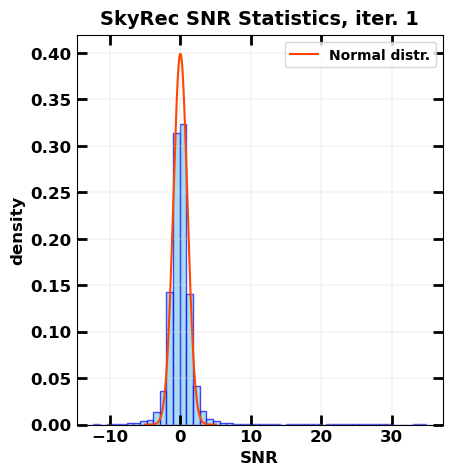

Number of outliers with SNR(σ) over 5 at iteration 1: 79


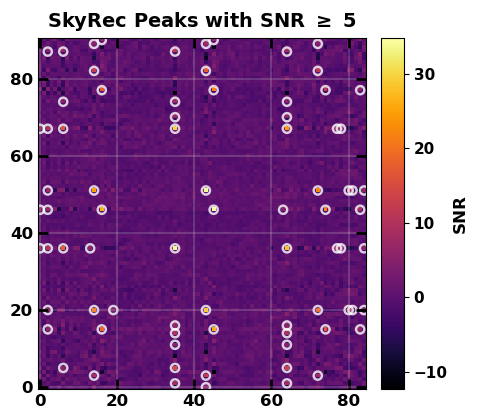

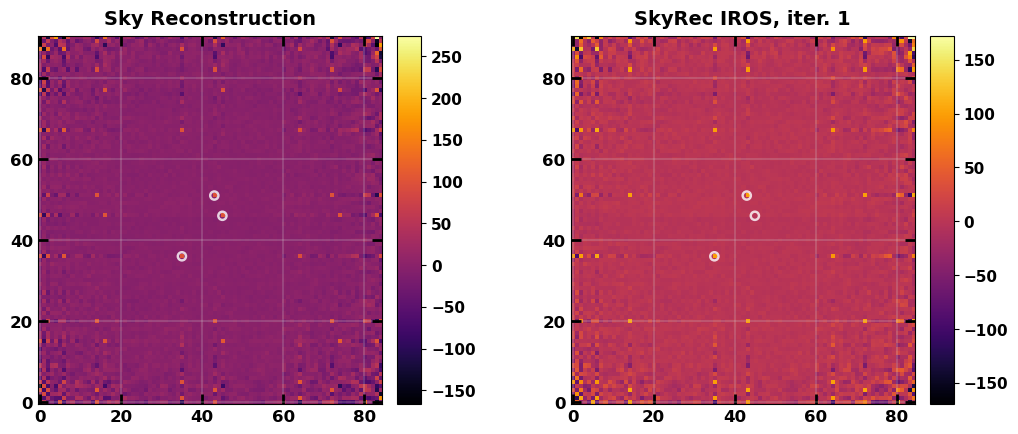

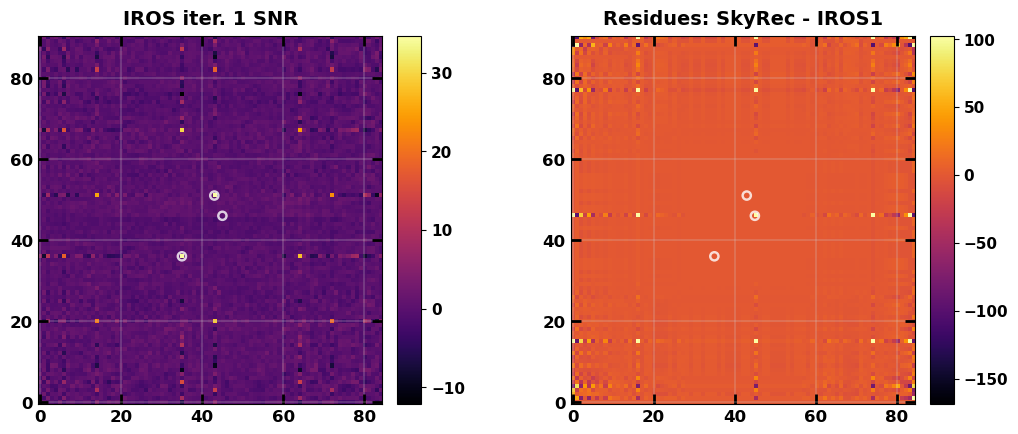

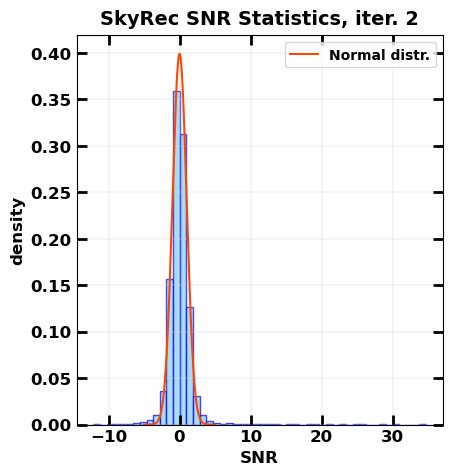

Number of outliers with SNR(σ) over 5 at iteration 2: 65


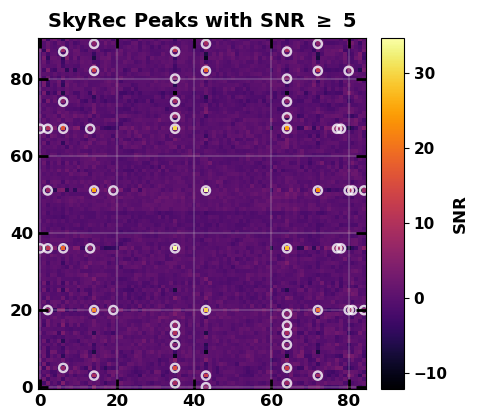

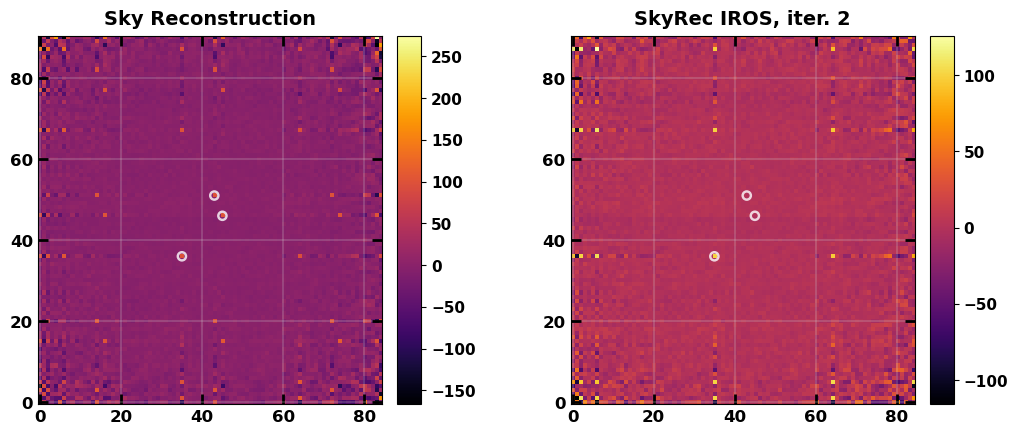

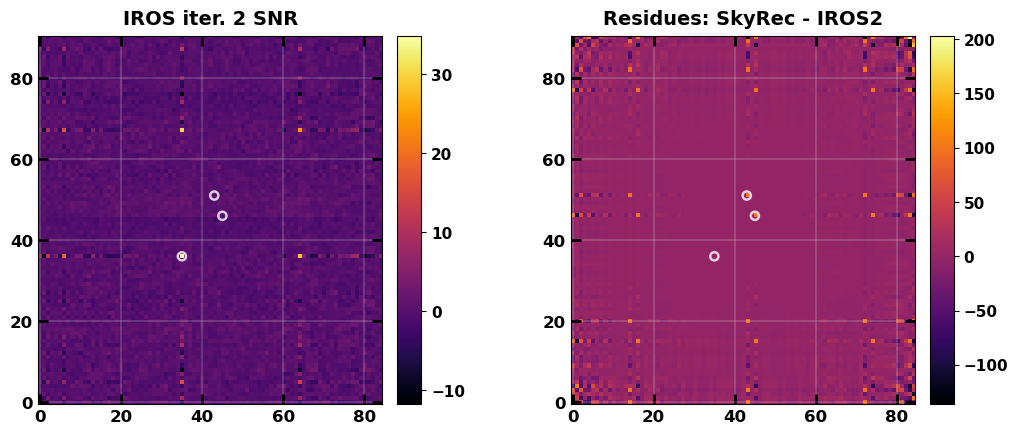

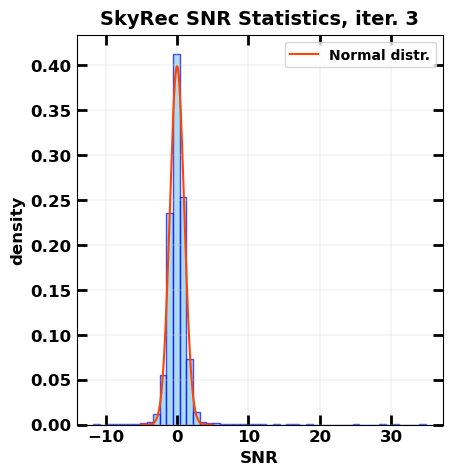

Number of outliers with SNR(σ) over 5 at iteration 3: 38


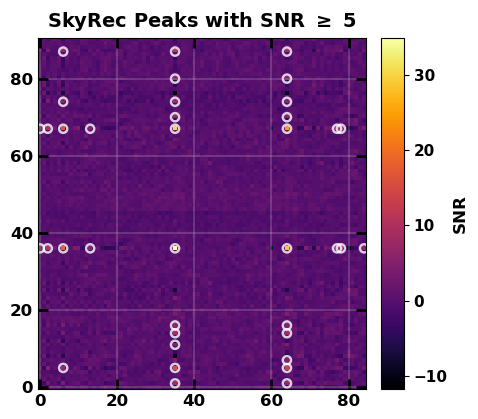

/home/starfloyd/PhD_Coding/MasksReconstructionTest/Img_ReconstructionMethods_2D/iros.py:41: RuntimeWarning: invalid value encountered in sqrt
  new_snr = np.nan_to_num(new_skyrec/np.sqrt(new_skyrec_var + 1e-8))


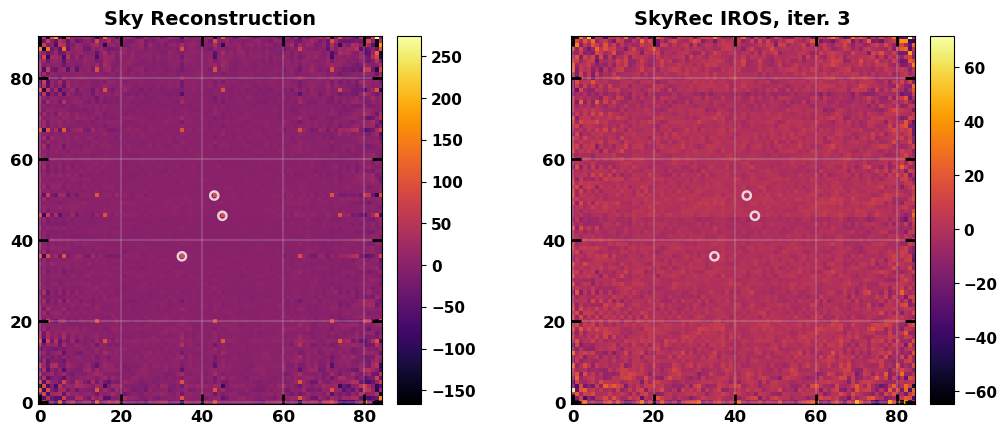

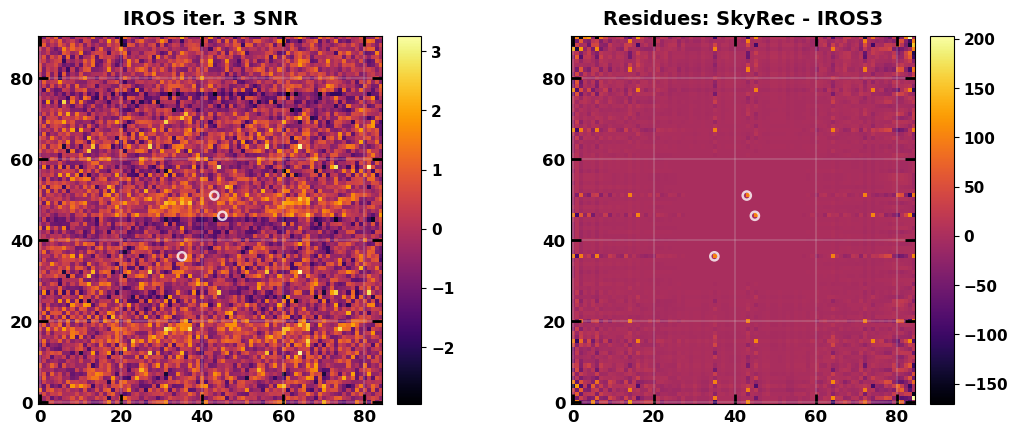

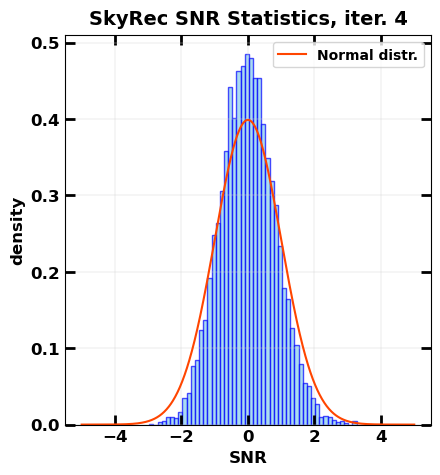

Number of outliers with SNR(σ) over 5 at iteration 4: 0


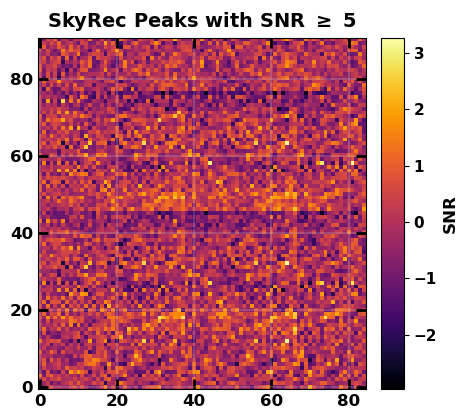

No sources detected with SNR over selected threshold...


In [75]:
iros = sk.IROS(
    n_iter=len(sources_flux) + 1,
    snr_threshold=5,
    skyrec=sky_reconstruction,
    skyrec_snr=snr,
    detector_image=fcfov_detector_image,
    source_pos=sources_pos,
    balancing_skyrec=balancing,
    vis_thres=300)

sources_dataset, iros_skyrec, iros_snr = iros.iterate(
    check_snr_norm=True,
    show_peaks=True,
    show_results=True)

- Let's look at the remaining image counts distribution

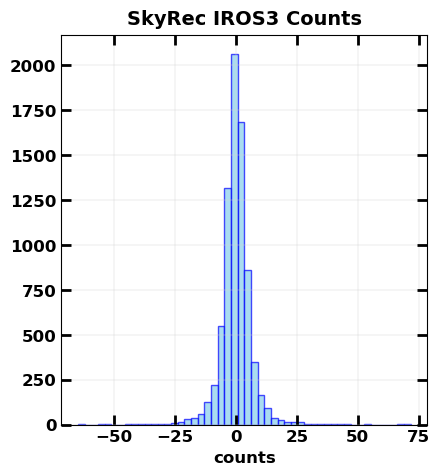

In [76]:
import matplotlib.pyplot as plt

post_iros_skyrec = iros_skyrec.copy()
post_iros_skyrec[iros_skyrec > 300] = 0
post_iros_skyrec[iros_skyrec < -300] = 0

fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.5))
fig.tight_layout()
ax.hist(post_iros_skyrec.reshape(-1), bins=50, color='SkyBlue', edgecolor='b', alpha=0.7)
ax.set_xlabel("counts", fontsize=12, fontweight='bold')
ax.set_title("SkyRec IROS3 Counts", fontsize=14, pad=8, fontweight='bold')
ax.grid(visible=True, color="lightgray", linestyle="-", linewidth=0.3)
ax.tick_params(which='both', direction='in', width=2)
ax.tick_params(which='major', length=7)
ax.tick_params(which='minor', length=4)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
plt.show()

- The remaining statistics should represent a normal distribution with zero mean because we have high counts, and also because in the balanced reconstruction we subtract a constant value in all the image

- Let's look at the removed sources and let's build a sky image with them to check if is consistent with the original simulated sources

In [77]:
sources_dataset

{'sources_pos': [array([46, 45]), array([51, 43]), array([36, 35])],
 'sources_counts': [np.float64(102.50170749814401),
  np.float64(100.81829687793723),
  np.float64(99.9250037168263)]}

In [79]:
iros_sky_image = np.zeros(sky_shape)
for i, pos, counts in zip(range(3), *sources_dataset.values()):
    print(f"Simulated Source S[{i}]: {sky_image[*pos]}\n"
          f"IROS Reconstructed Source IROS_S_hat[{i}]: {counts:.2f} pm {np.sqrt(counts):.2f}\n")

Simulated Source S[0]: 102.0
IROS Reconstructed Source IROS_S_hat[0]: 102.50 pm 10.12

Simulated Source S[1]: 101.0
IROS Reconstructed Source IROS_S_hat[1]: 100.82 pm 10.04

Simulated Source S[2]: 101.0
IROS Reconstructed Source IROS_S_hat[2]: 99.93 pm 10.00



<br>

### **Sky Image with Sources also in the PCFOV**

- Let's see how IROS behave with sources of different strength and in the PCFOV

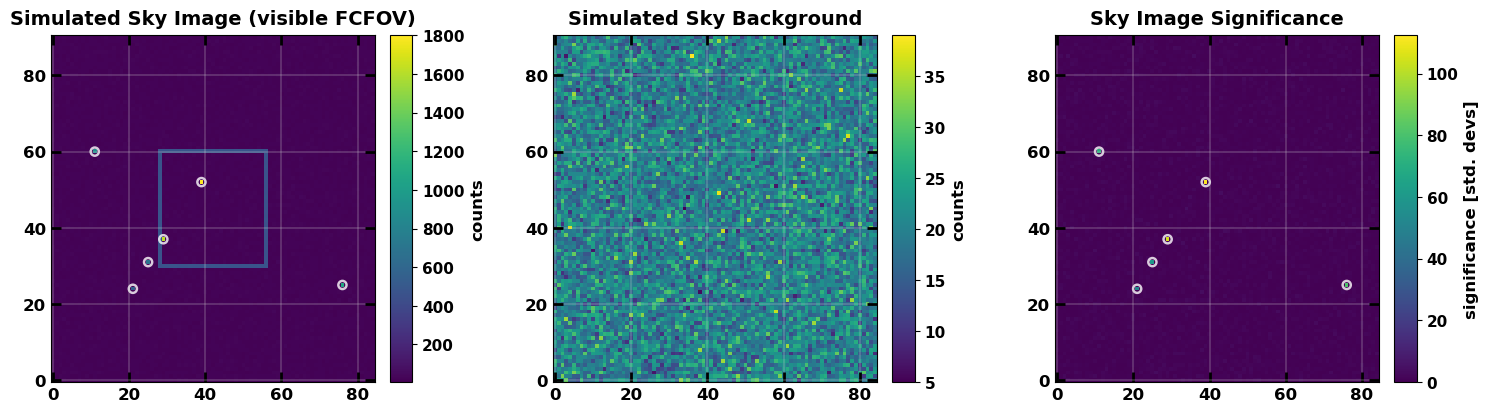

/tmp/ipykernel_34676/2302791192.py:38: RuntimeWarning: invalid value encountered in sqrt
  snr = np.nan_to_num(sky_reconstruction/np.sqrt(skyrec_var + 1e-8))


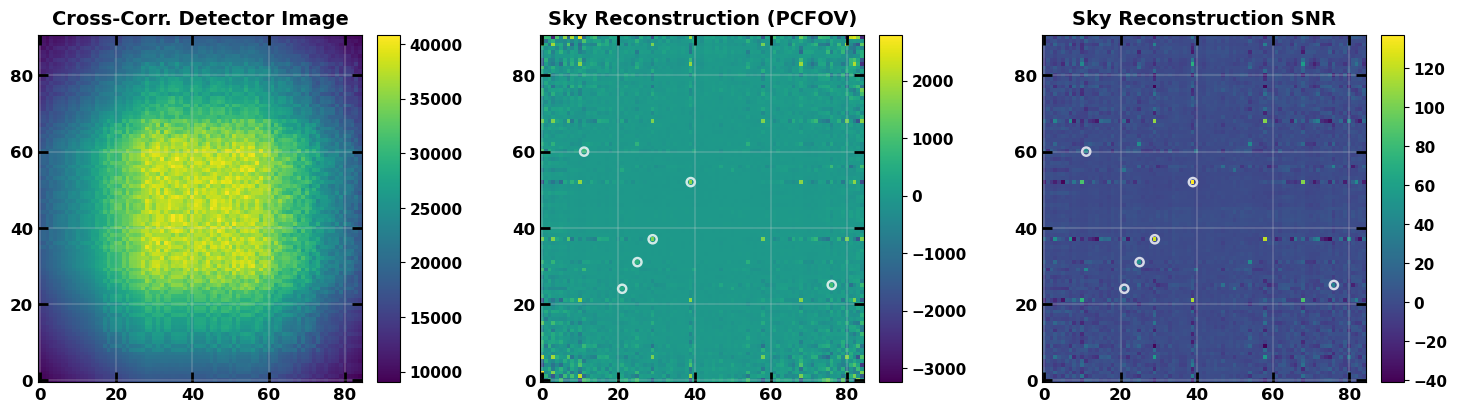

In [8]:
h, v = n - 1, m - 1
sky_shape = (n + 2*h, m + 2*v)

sources_flux = np.random.randint(int(5e2), int(2e3), size=6)
sources_pos = None
sky_background_rate = 20

sky_image, sky_background, sources_pos = sky_image_simulation(sky_shape, sources_flux, sources_pos, sky_background_rate)
sky_significance = stats.significance(sky_image, sky_background_rate)

highlight_fcfov = True
if highlight_fcfov:
    base = np.zeros((n - 2, m - 2), dtype=int)
    c_edge = np.pad(base, pad_width=[(1, 1), (1, 1)], constant_values=sources_flux.max()//4)

    sky_image_wfcfov = sky_image.copy()
    sky_image_wfcfov[h : -h, v : -v] += c_edge

    plot.image_plot([sky_image_wfcfov, sky_background, sky_significance],
                    ["Simulated Sky Image (visible FCFOV)", "Simulated Sky Background", "Sky Image Significance"],
                    cbarlabel=["counts", "counts", "significance [std. devs]"], 
                    cbarcmap=["viridis"]*3,
                    simulated_sources=[sources_pos, None, sources_pos])


cc_detector_image = correlate(mask, sky_image, mode='full')[h : -h, v : -v]
fcfov_detector_image = cc_detector_image[h : -h, v : -v]

bulk_array = np.ones(fcfov_detector_image.shape)
balancing = bal.BalancedSkyReconstruction_Goldwurm(mask, decoder, bulk_array)
sky_reconstruction, skyrec_var = balancing.balanced_sky_reconstruction(fcfov_detector_image)

threshold = 3*sources_flux.max()
post_sky_reconstruction = sky_reconstruction.copy()
post_sky_reconstruction[sky_reconstruction > threshold] = 0     # remove artifacts
post_sky_reconstruction[sky_reconstruction < -threshold] = 0

snr = np.nan_to_num(sky_reconstruction/np.sqrt(skyrec_var + 1e-8))

plot.image_plot([cc_detector_image, post_sky_reconstruction, snr],
                ["Cross-Corr. Detector Image", "Sky Reconstruction (PCFOV)", "Sky Reconstruction SNR"],
                cbarcmap=["viridis"]*3,
                simulated_sources=[None, sources_pos, sources_pos])

In [9]:
sources_flux

array([1624,  552,  694,  897, 1800, 1090])

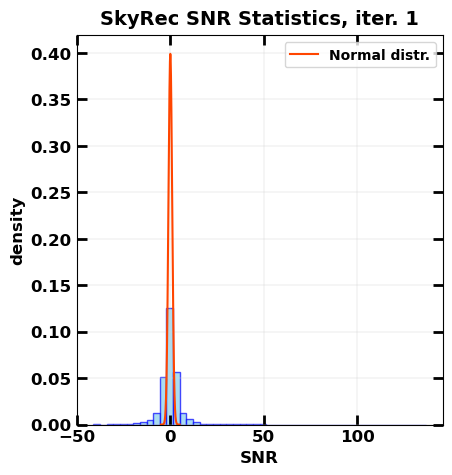

Number of outliers with SNR(σ) over 5 at iteration 1: 681


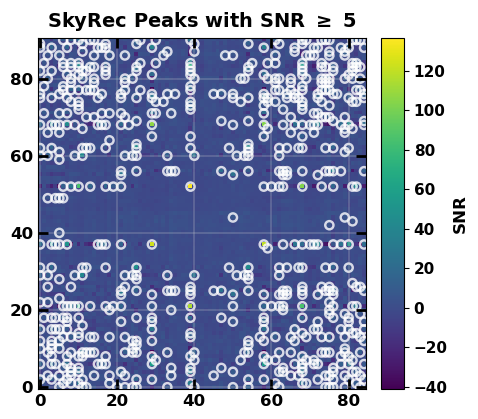

/home/starfloyd/PhD_Coding/MasksReconstructionTest/Img_ReconstructionMethods_2D/iros.py:41: RuntimeWarning: invalid value encountered in sqrt
  new_snr = np.nan_to_num(new_skyrec/np.sqrt(new_skyrec_var + 1e-8))


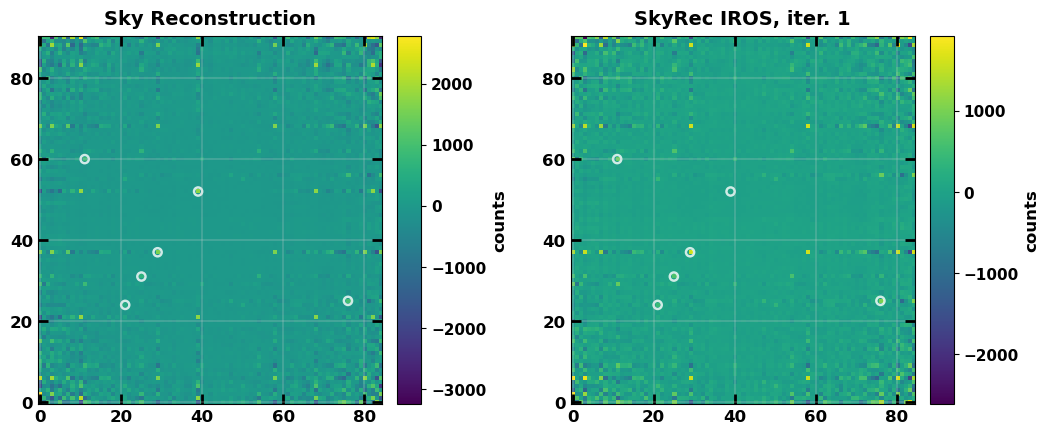

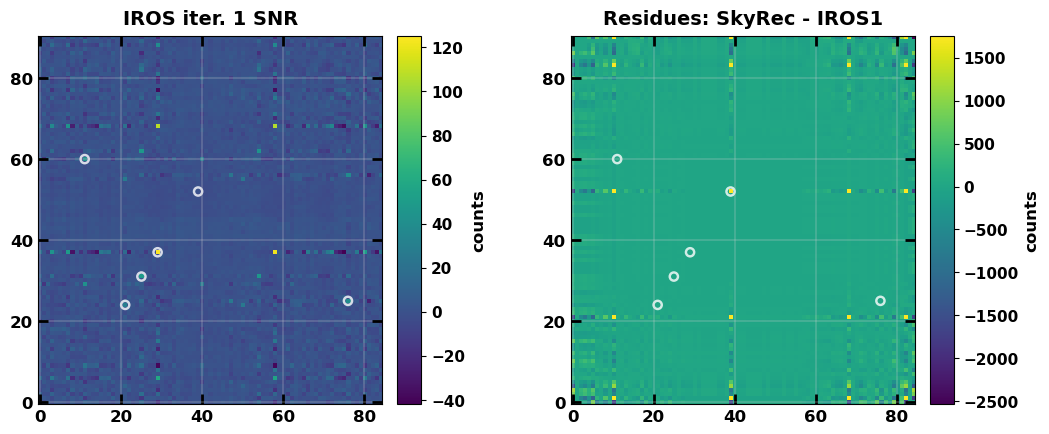

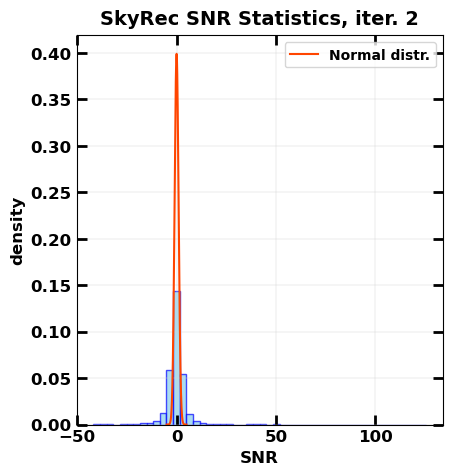

Number of outliers with SNR(σ) over 5 at iteration 2: 536


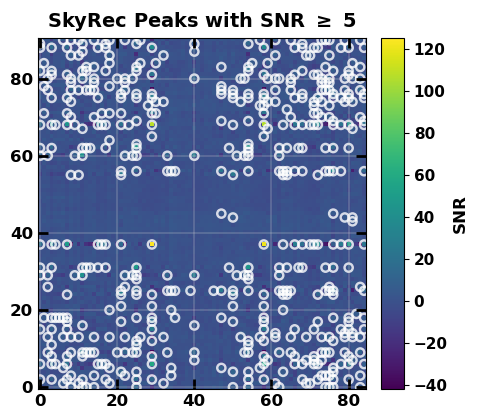

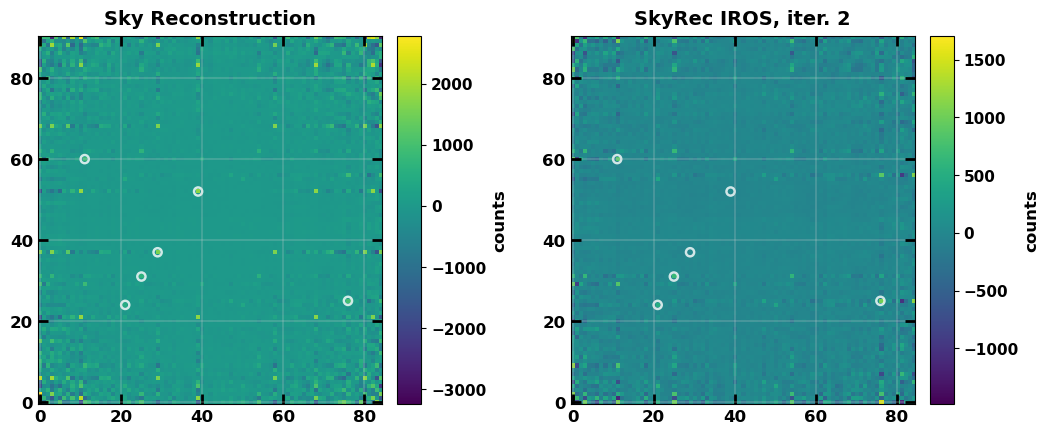

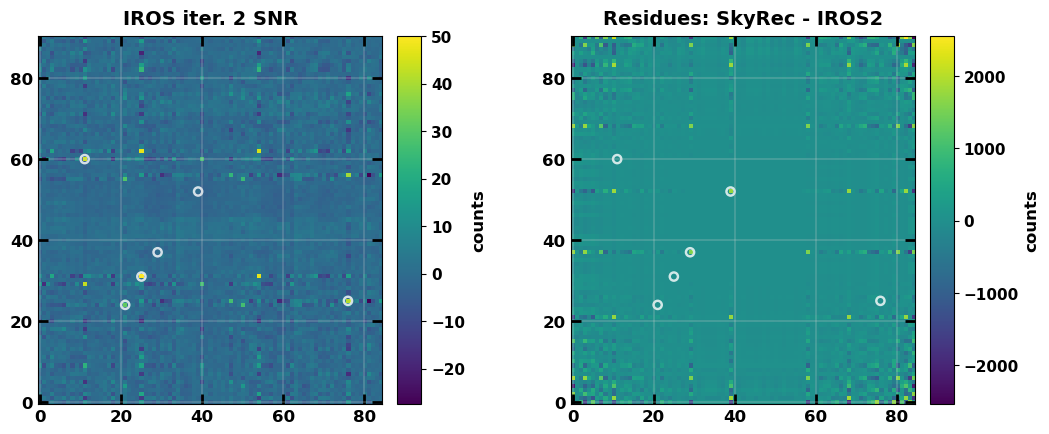

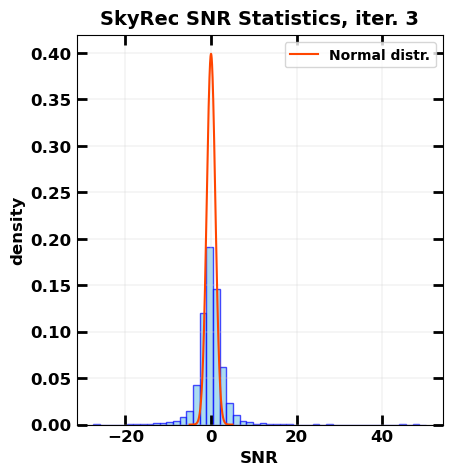

Number of outliers with SNR(σ) over 5 at iteration 3: 299


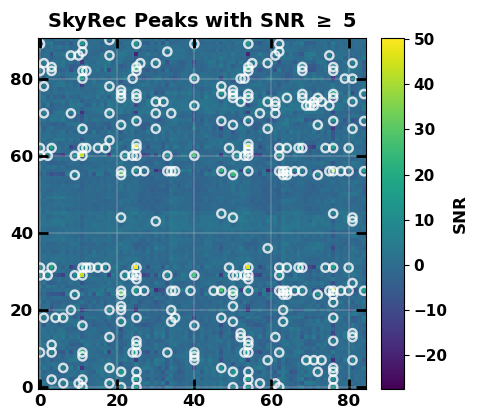

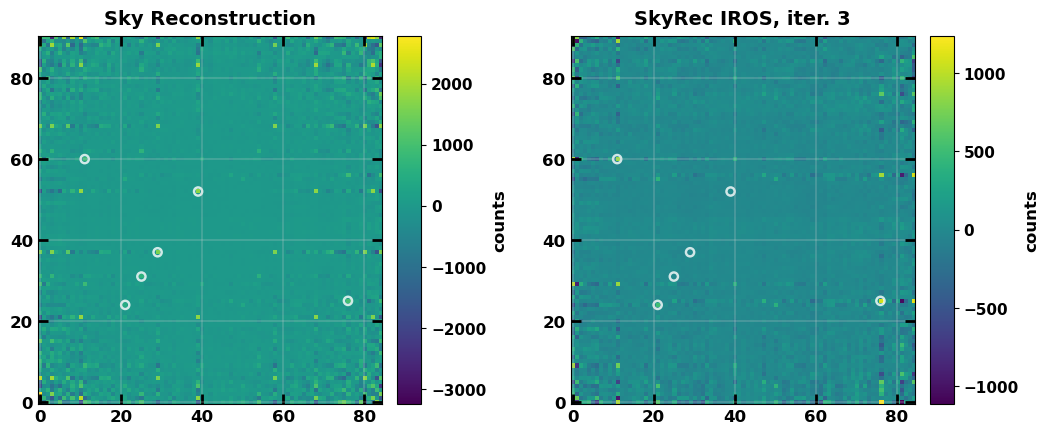

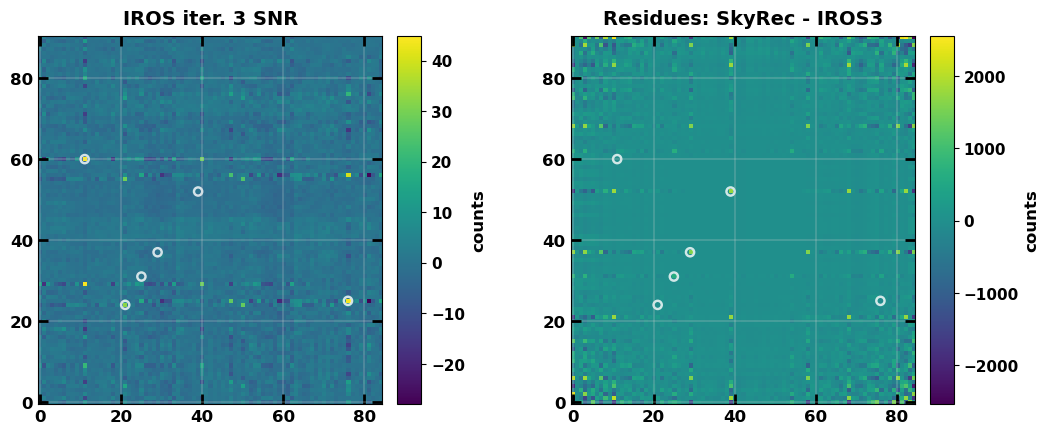

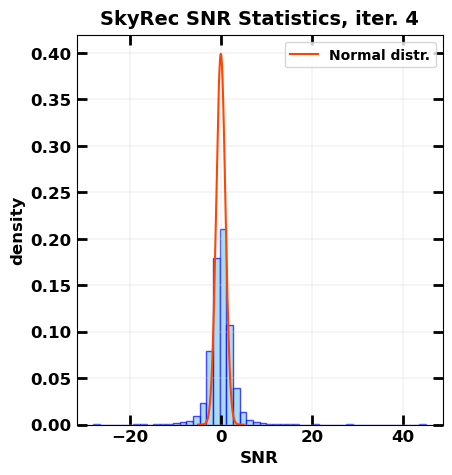

Number of outliers with SNR(σ) over 5 at iteration 4: 202


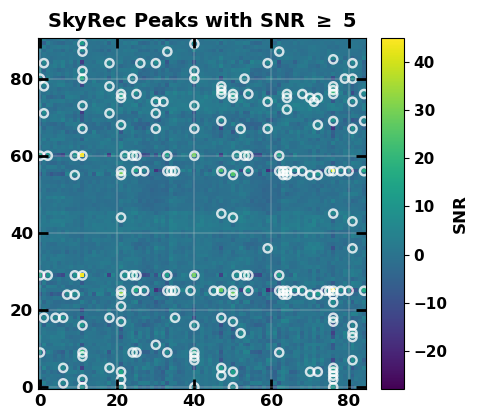

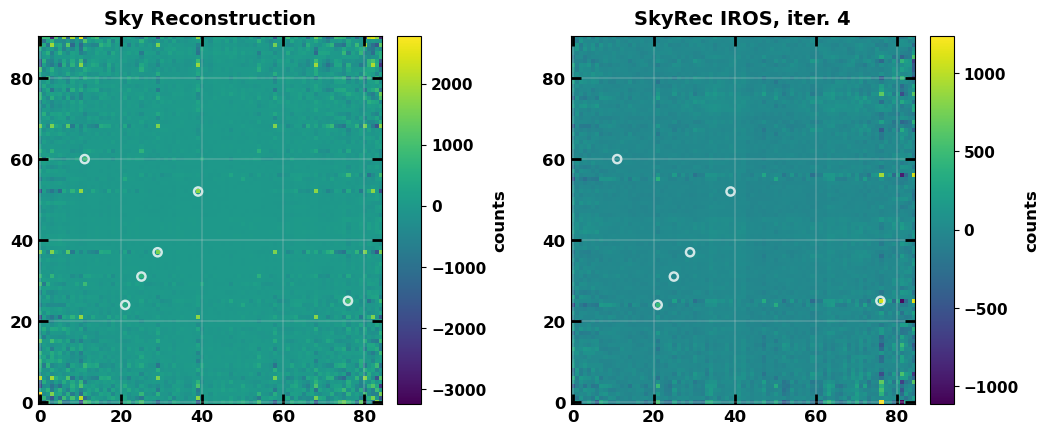

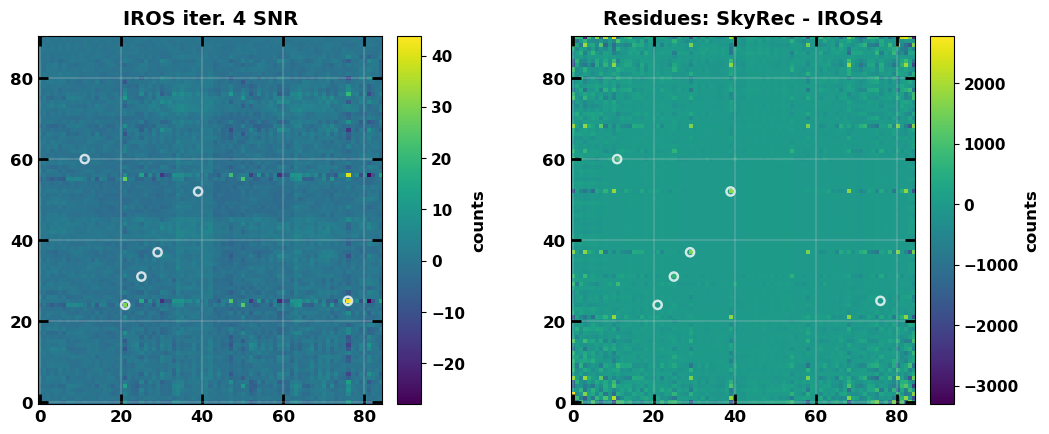

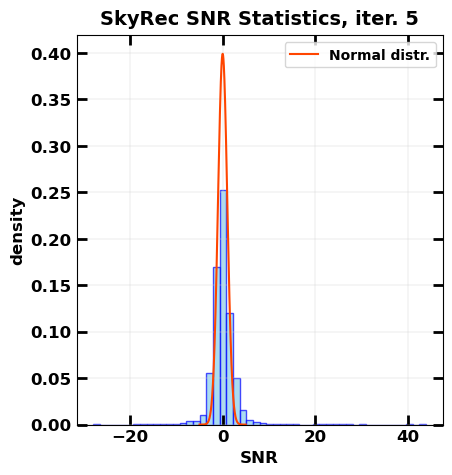

Number of outliers with SNR(σ) over 5 at iteration 5: 138


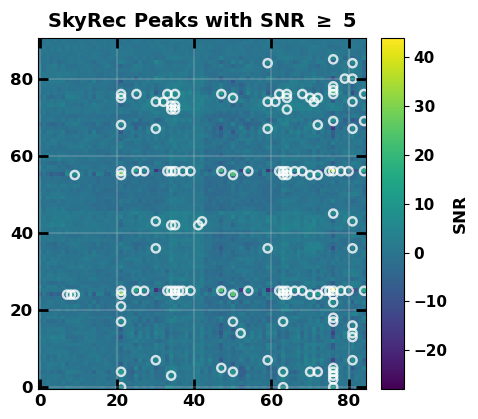

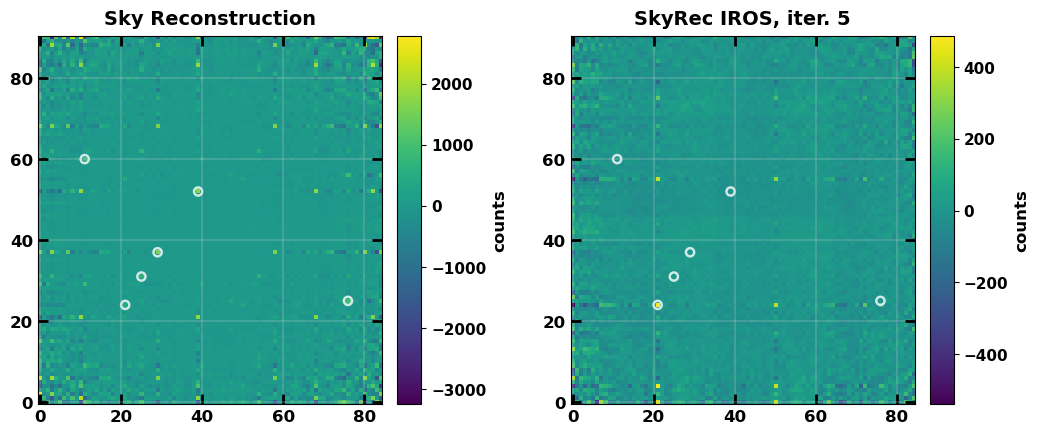

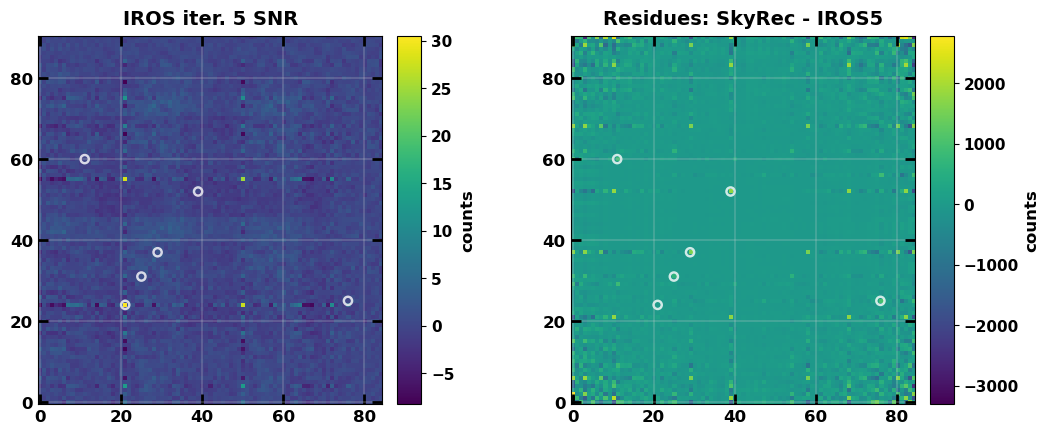

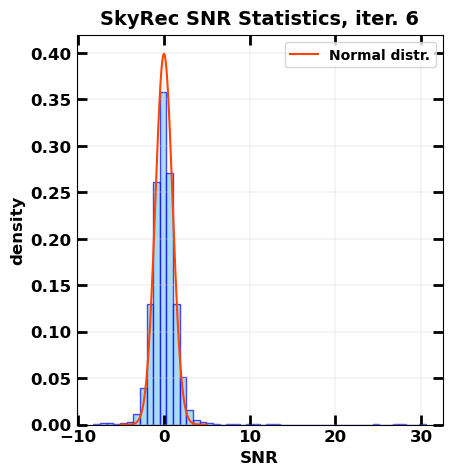

Number of outliers with SNR(σ) over 5 at iteration 6: 26


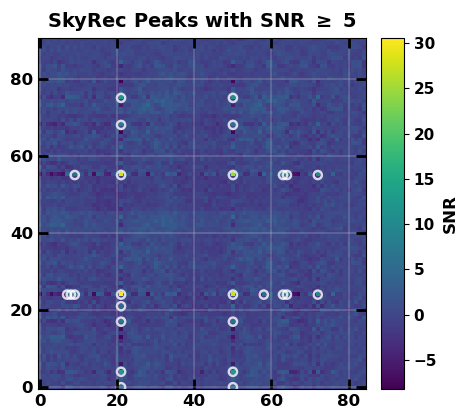

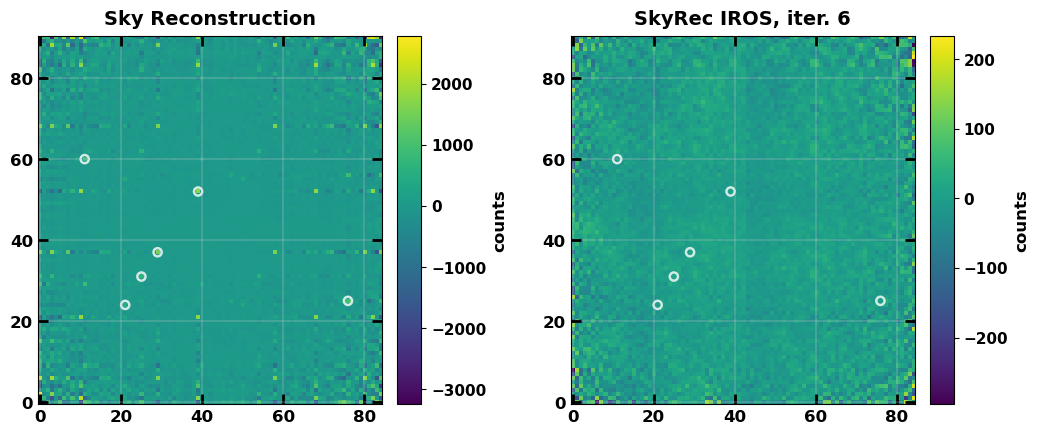

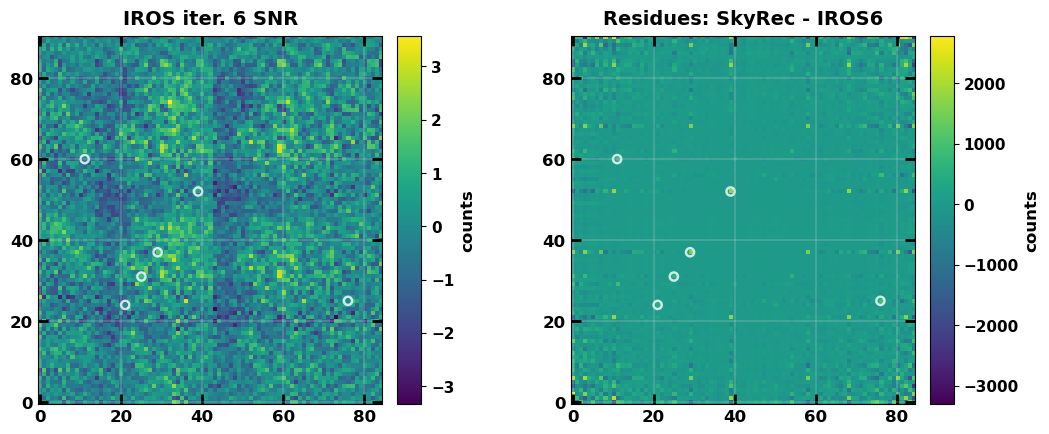

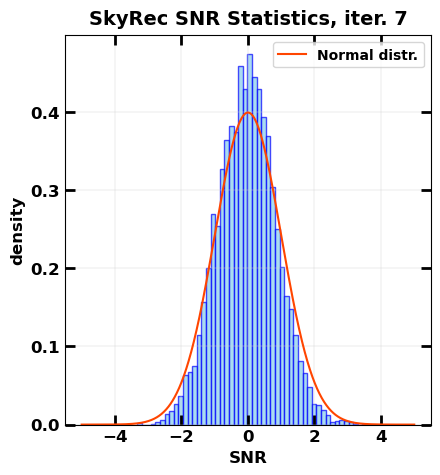

Number of outliers with SNR(σ) over 5 at iteration 7: 0


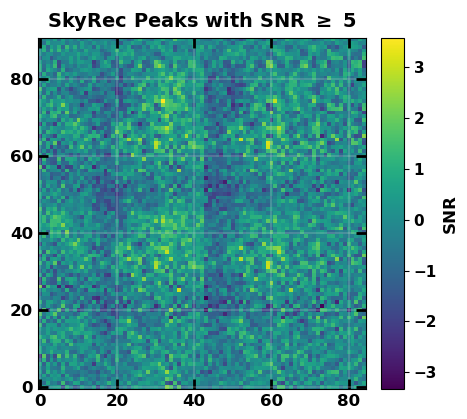

No sources detected with SNR over selected threshold...


In [13]:
iros = sk.IROS(
    n_iter=len(sources_flux) + 6,
    snr_threshold=5,
    skyrec=sky_reconstruction,
    skyrec_snr=snr,
    detector_image=fcfov_detector_image,
    source_pos=sources_pos,
    balancing_skyrec=balancing,
    vis_thres=threshold)

sources_dataset, iros_skyrec, iros_snr = iros.iterate(
    check_snr_norm=True,
    show_peaks=True,
    show_results=True)

Simulated Source S[0]: 1800
IROS Reconstructed Source S_hat[0]: 1761 pm 42
|S_hat[0] - S[0]| < std(S_hat[0]): True

Simulated Source S[1]: 1624
IROS Reconstructed Source S_hat[1]: 1596 pm 40
|S_hat[1] - S[1]| < std(S_hat[1]): True

Simulated Source S[2]: 694
IROS Reconstructed Source S_hat[2]: 668 pm 26
|S_hat[2] - S[2]| < std(S_hat[2]): False

Simulated Source S[3]: 897
IROS Reconstructed Source S_hat[3]: 878 pm 30
|S_hat[3] - S[3]| < std(S_hat[3]): True

Simulated Source S[4]: 1090
IROS Reconstructed Source S_hat[4]: 1083 pm 33
|S_hat[4] - S[4]| < std(S_hat[4]): True

Simulated Source S[5]: 552
IROS Reconstructed Source S_hat[5]: 488 pm 22
|S_hat[5] - S[5]| < std(S_hat[5]): False

Total simulated sources: 6
Total reconstructed sources: 6


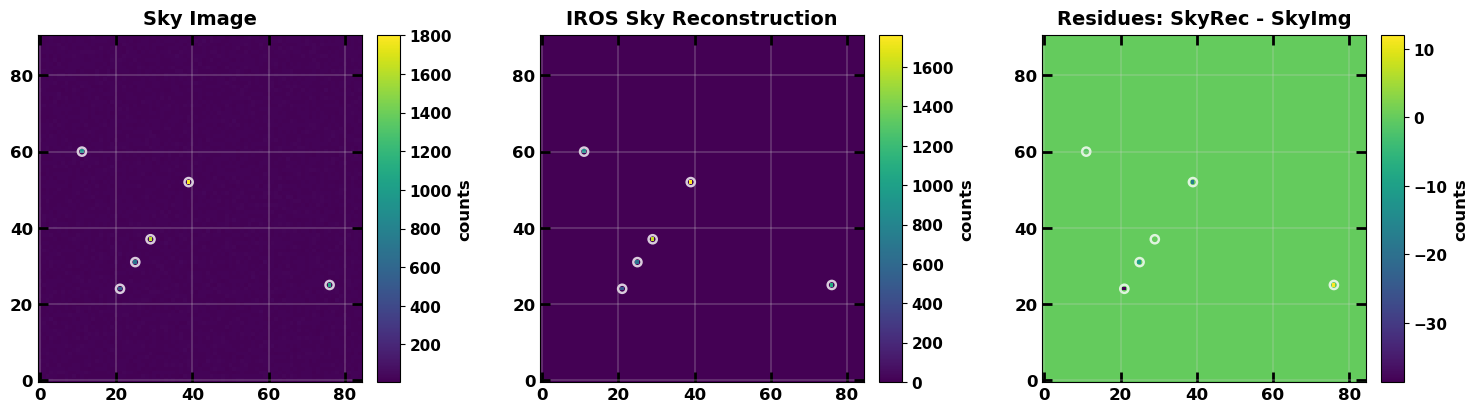

In [17]:
iros_sky_image = np.zeros(sky_shape)
for idx, loc in enumerate(sources_dataset['sources_pos']):
    iros_sky_image[*loc] = sources_dataset['sources_counts'][idx]


for i, pos, counts in zip(range(len(sources_flux)), *sources_dataset.values()):
    print(f"Simulated Source S[{i}]: {sky_image[*pos]}\n"
          f"IROS Reconstructed Source S_hat[{i}]: {counts:.0f} pm {np.sqrt(counts):.0f}\n"
          f"|S_hat[{i}] - S[{i}]| < std(S_hat[{i}]): {np.abs(counts - sky_image[*pos]) < np.sqrt(counts)}\n")

print(f"Total simulated sources: {len(sources_flux)}\n"
      f"Total reconstructed sources: {len(sources_dataset['sources_counts'])}")


plot.image_plot([sky_image, iros_sky_image, iros_sky_image - sky_image + sky_background],
                ["Sky Image", "IROS Sky Reconstruction", "Residues: SkyRec - SkyImg"],
                cbarlabel=["counts"]*3,
                cbarcmap=["viridis"]*3,
                simulated_sources=[sources_pos, sources_dataset['sources_pos'], sources_pos])